In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio
import io
from IPython.display import Image, display

# Asegurarnos de usar un backend que no abra ventanas
import matplotlib
matplotlib.use('Agg')

In [16]:
def getBaseForm():
    # Definimos los puntos de una 'casa' simple
    puntos = np.array([
        [-0.5, -0.5, 1], # Base izq
        [0.5, -0.5, 1],  # Base der
        [0.5, 0.5, 1],   # Techo der
        [0, 1, 1],       # Punta techo
        [-0.5, 0.5, 1],  # Techo izq
        [-0.5, -0.5, 1]  # Volver al inicio
    ]).T
    
    return puntos

# Matriz de transformacion para dezplazar 3x3
def translate(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])


# Matriz de transformacion para rotar 3x3
def rotate(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ])

# Matriz de transformacion para escalar 3x3
def scale(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])

In [17]:
points = getBaseForm()
frameNumber = 40
frames = []

print("Generando frames...")

for i in range(frameNumber):
    t = i / frameNumber  # Tiempo de 0 a 1
    
    # Parámetros dinámicos (Interpolación en función del tiempo)
    angle = 2 * np.pi * t
    tx = 2 * np.cos(angle)
    ty = 1.5 * np.sin(angle * 2) # Movimiento en infinito
    s = 1 + 0.5 * np.sin(angle)
    
    # Construir la transformación combinada (Traslación * Rotación * Escala)
    # El orden importa: Primero escalamos, luego rotamos, luego trasladamos
    T = translate(tx, ty)
    R = rotate(angle)
    S = scale(s, s)
    
    # Multiplicar matrices de transformación
    M = T @ R @ S
    
    newPoints = M @ points
    
    # Crear figura
    fig, ax = plt.subplots(figsize=(6,6), dpi=100)
    ax.plot(newPoints[0, :], newPoints[1, :], 'r-o', linewidth=2, markersize=5)
    
    # Decoración
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_aspect('equal')
    
    # Mostrar la matriz resultante en el título
    matriz_str = np.array2string(M, precision=2, suppress_small=True)
    ax.set_title(f"Frame {i} | Time {t:.2f}\nMatriz M:\n{matriz_str}", fontsize=9, family='monospace')
    
    # Capturar frame usando un buffer
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(imageio.v3.imread(buf))
    plt.close(fig)

# Make dist if not exist
os.makedirs("./dist", exist_ok=True)

print("Guardando GIF...")
gifName = "dist/" + "transformacion_animada.gif"
imageio.mimsave(gifName, frames, fps=15, loop=0)
print(f"¡Listo! GIF guardado como {gifName}")

Generando frames...
Guardando GIF...
¡Listo! GIF guardado como dist/transformacion_animada.gif


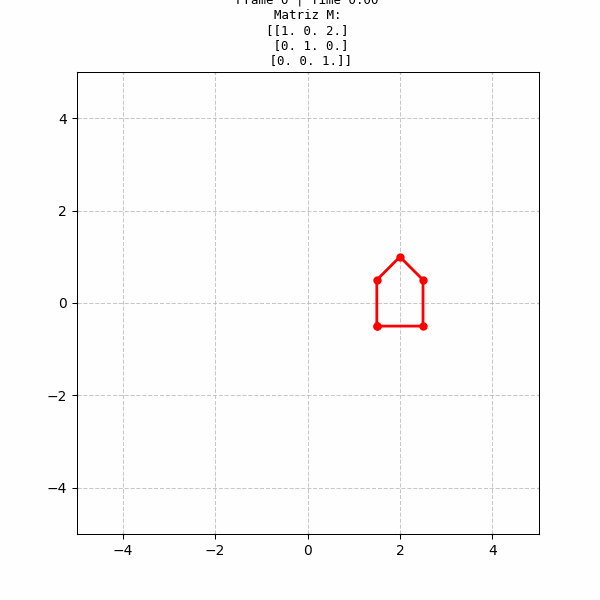

In [18]:
# Mostrar el GIF
display(Image(filename=gifName))